# Class 6 Review: From Python Basics to Clear Visualizations

Before beginning Class 7, we will review the workflow from **Software for Data Analysis II**.

In Class 6, we moved from simply running Python commands to using Python to **summarize, visualize, and communicate data**.

### Class 6 workflow

1. Load and inspect a dataset.
2. Identify the question.
3. Analyze one variable at a time.
4. Count categories and calculate percentages.
5. Check missing values.
6. Choose a chart that matches the question.
7. Create bar charts, histograms, box plots, and line charts.
8. Use `groupby()` to summarize records.
9. Improve chart clarity.
10. Write a short evidence-based insight.

### Today’s bridge

Class 6 focused mainly on **univariate analysis** — one variable at a time.

Class 7 moves into **bivariate analysis** — comparing **two variables** to look for differences, patterns, or relationships.

## Review Vocabulary from Class 6

| Term | Meaning |
|---|---|
| **DataFrame** | A table-like pandas object with rows and columns. |
| **Univariate analysis** | Analysis of one variable at a time. |
| **Categorical variable** | A variable made of labels or groups, such as borough. |
| **Numeric variable** | A variable containing measurable quantities. |
| **Frequency / count** | The number of observations in a category. |
| **Percentage** | A category's share of a total. |
| **Missing value** | A value that is absent or unavailable. |
| **Distribution** | How numeric observations are spread across values. |
| **Histogram** | A chart showing the distribution of a numeric variable. |
| **Box plot** | A chart summarizing center, spread, and possible outliers. |
| **Line chart** | A chart commonly used to show change over time. |
| **`groupby()`** | A pandas method for dividing data into groups before summarizing it. |
| **Insight statement** | A concise statement describing an observed result with evidence and context. |

## Class 6 Review Questions

Try to answer these before revealing the notes below.

1. What does `df.head()` do?
2. What does `df.shape` tell us?
3. What does `value_counts()` do?
4. Why might we use `normalize=True`?
5. What is the difference between a bar chart and a histogram?
6. What does a box plot help us see?
7. Why do we use a line chart for dates or time?
8. What does `groupby()` allow us to do?
9. Why should a chart title describe the question or takeaway?
10. Why should we avoid claiming that 311 request counts directly measure neighborhood conditions?

### Class 6 Review — Answers

- `df.head()` previews the first rows.
- `df.shape` returns the number of rows and columns.
- `value_counts()` counts observations in each category.
- `normalize=True` converts counts to proportions; multiplying by 100 gives percentages.
- A **bar chart** compares categories; a **histogram** shows the distribution of a numeric variable.
- A **box plot** summarizes center and spread and can reveal unusual values.
- A **line chart** preserves time order and helps show change over time.
- `groupby()` divides observations into groups so we can calculate counts, means, or other summaries.
- Clear titles and labels help the audience understand the chart quickly.
- 311 requests are **recorded reports**. Reporting behavior, population, access, and other factors affect the counts.

# Class 7 — Software for Data Analysis III
## Bivariate Analysis with Python

**Accelerated Data Analytics — NYU SPS / COOP**

### Datasets used today

- **August 311 service requests**
- **Old Faithful observations**

### Main idea

> **Univariate analysis asks what one variable looks like. Bivariate analysis asks how two variables compare or relate.**

# Learning Objectives

By the end of Class 7, you should be able to:

1. Compare two variables using Python.
2. Summarize data by group with `groupby()`.
3. Build cross-tabulations for two categorical variables.
4. Calculate counts and percentages within groups.
5. Compare a categorical variable with a numeric variable using grouped averages.
6. Use a scatterplot to examine two numeric variables.
7. Interpret relationships carefully without assuming causation.
8. Write a plain-English finding supported by numerical evidence.

# Vocabulary

| Term | Meaning |
|---|---|
| **Bivariate analysis** | Analysis involving two variables. |
| **Cross-tabulation / crosstab** | A table showing counts or percentages for combinations of two categorical variables. |
| **Grouped summary** | A statistic calculated separately for categories or groups. |
| **Grouped average** | The mean of a numeric variable calculated within each category. |
| **Denominator** | The total used when calculating a proportion or percentage. |
| **Scatterplot** | A graph showing paired values for two numeric variables. |
| **Association / relationship** | A pattern in which two variables vary together. |
| **Causation** | A claim that a change in one variable produces a change in another. |
| **Mean** | Arithmetic average. |
| **Median** | Middle value after observations are ordered. |

# 1. What Is Bivariate Analysis?

**Bi** means **two**.

Bivariate analysis examines **two variables together**.

Examples from today's datasets:

- **Borough + complaint type** — Do complaint patterns differ across boroughs?
- **Borough + status** — Does the recorded status mix differ by borough?
- **Eruption-duration group + waiting time** — Does average waiting time differ between groups?
- **Eruption duration + waiting time** — Do longer eruptions tend to occur with longer waiting intervals?

The method we choose depends on the **types of the two variables**.

## Match the Method to the Variables

| Variable combination | Dataset example | Starting method |
|---|---|---|
| Categorical + categorical | Borough and complaint type | Cross-tabulation + grouped bar chart |
| Categorical + numeric | Eruption-duration group and waiting time | Grouped averages |
| Numeric + numeric | Eruption duration and waiting time | Scatterplot |

### Key question

Before writing code, ask:

> **What type of variable is each one?**

# 2. Load the Data and Libraries

We will use `pandas` for data analysis and `matplotlib` for charts.

**Google Colab setup:** The August 311 file will download using the provided Google Drive file ID. Run the next setup cell before loading the data. The file must be accessible to you through its Drive sharing settings.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Download August 311 using the class Google Drive file ID.
csv_filename = "August_311.csv"
file_id = "1Ayf4NjJGKVpXjDscRhyAAULzrjOUHKSb"
url = f"https://drive.google.com/uc?id={file_id}"

try:
    import google.colab
except ImportError:
    print(f"Google Colab not detected. Looking for local file: {csv_filename}")
else:
    try:
        import gdown
    except ImportError:
        !pip install -q gdown
        import gdown

    gdown.download(url, csv_filename, quiet=False)

if not os.path.exists(csv_filename):
    raise FileNotFoundError(
        f"{csv_filename} was not found. Check that the Drive file can be downloaded."
    )

august311 = pd.read_csv(csv_filename, low_memory=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Ayf4NjJGKVpXjDscRhyAAULzrjOUHKSb
From (redirected): https://drive.google.com/uc?id=1Ayf4NjJGKVpXjDscRhyAAULzrjOUHKSb&confirm=t&uuid=0de22519-28ab-4a7b-8a67-408843d45359
To: /content/August_311.csv
100%|██████████| 289M/289M [00:02<00:00, 108MB/s]


## Load the August 311 Dataset

The Class 6 file may use display-style column names such as `Borough` and `Problem (formerly Complaint Type)`.

For Class 7, we will create simplified working names:

- `borough`
- `complaint_type`
- `status`

This makes the bivariate commands easier to read.

In [3]:
# Load the downloaded August 311 file into the DataFrame used throughout class.
if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"{csv_filename} was not found. Check the download or local filename.")

august311 = pd.read_csv(csv_filename, low_memory=False)
print("August 311 data loaded successfully!")

# Create consistent working column names when the original columns are available.
rename_map = {
    "Borough": "borough",
    "borough": "borough",
    "Problem (formerly Complaint Type)": "complaint_type",
    "Complaint Type": "complaint_type",
    "complaint_type": "complaint_type",
    "Status": "status",
    "status": "status"
}

august311 = august311.rename(columns={k:v for k,v in rename_map.items() if k in august311.columns})

august311.head()

August 311 data loaded successfully!


,Unique Key,Created Date,Closed Date,Agency,Agency Name,complaint_type,Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,70259761,08/31/2026 11:59:50 PM,09/02/2026 02:11:15 PM,TLC,Taxi and Limousine Commission,Lost Property,Bag/Wallet,Wallet,Taxi,10013,...,NaN,NaN,"231 HUDSON STREET, MANHATTAN (NEW YORK), NY, 1...",NaN,NaN,NaN,NaN,40.724282,-74.007840,POINT (-74.007839675607 40.724281751473)
1,70255217,08/31/2026 11:59:30 PM,NaN,TLC,Taxi and Limousine Commission,For Hire Vehicle Complaint,Driver Complaint - Non Passenger,Unsafe Driving,Street,11211,...,NaN,NaN,"636 GRAND STREET, BROOKLYN, NY, 11211",NaN,NaN,NaN,NaN,40.711369,-73.946691,POINT (-73.946691151302 40.711369303559)
2,70257205,08/31/2026 11:59:27 PM,09/01/2026 01:34:39 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,NaN,Street/Sidewalk,11691,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.603358,-73.753866,POINT (-73.75386629509 40.603358017906)
3,70258319,08/31/2026 11:59:25 PM,NaN,HPD,Department of Housing Preservation and Develop...,DOOR/WINDOW,WINDOW FRAME,LOOSE OR DEFECTIVE,RESIDENTIAL BUILDING,11368,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.748623,-73.860494,POINT (-73.860494398392 40.748623091636)
4,70259363,08/31/2026 11:59:21 PM,09/01/2026 12:40:00 AM,DEP,Department of Environmental Protection,Sewer Maintenance,Backup,NaN,Sewer,10467,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.881926,-73.862873,POINT (-73.862872685544 40.881926161908)


In [4]:
# Review the structure of the August 311 dataset.
august311.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328400 entries, 0 to 328399
Data columns (total 44 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unique Key                            328400 non-null  int64  
 1   Created Date                          328400 non-null  object 
 2   Closed Date                           279315 non-null  object 
 3   Agency                                328400 non-null  object 
 4   Agency Name                           328400 non-null  object 
 5   complaint_type                        328400 non-null  object 
 6   Problem Detail (formerly Descriptor)  321162 non-null  object 
 7   Additional Details                    102414 non-null  object 
 8   Location Type                         299672 non-null  object 
 9   Incident Zip                          325701 non-null  object 
 10  Incident Address                      319192 non-null  object 
 11  

## Meet the August 311 Dataset

As a class, identify:

- What does one row represent?
- What year does the file cover?
- What geographic area does it cover?
- What date range or extraction period does the supplied file represent?

### Interpretation note

**Requests measure recorded reports. They do not directly measure every underlying neighborhood condition.**

That distinction becomes especially important when comparing boroughs.

# 3. Check Categories and Missing Values

Before comparing categories, inspect the labels.

Why?

Suppose one borough appears as both:

- `BROOKLYN`
- `Brooklyn`

Python may treat these as **different categories**.

Missing values can also change the number of records included in a comparison.

In [5]:
# Inspect borough labels, including missing values.
august311["borough"].value_counts(dropna=False)

,count
borough,
BROOKLYN,103741
QUEENS,84602
BRONX,64166
MANHATTAN,62379
STATEN ISLAND,13144
Unspecified,368


In [6]:
# Inspect status labels, including missing values.
august311["status"].value_counts(dropna=False)

,count
status,
Closed,272806
Open,28112
In Progress,26081
Assigned,1216
Pending,164
Unspecified,21


In [7]:
# Check missing values in the variables used today.
august311[["borough", "complaint_type", "status"]].isna().sum()

,0
borough,0
complaint_type,0
status,0


## Discussion

Look for:

- Unknown or missing boroughs
- Inconsistent spelling or capitalization
- Missing complaint types
- Missing status values

### Prompt

> **How could inconsistent categories or missing values affect a comparison?**

A comparison is only as reliable as the categories and measurements used to build it.

# 4. How `groupby()` Works

`groupby()` follows a simple pattern:

### 1. Split
Divide records into groups.

### 2. Apply
Calculate a summary for each group.

### 3. Combine
Return the summaries as a table.

General pattern:

```python
df.groupby("group")["outcome"].mean()
```

Think of it as:

> **Group the rows → calculate something → compare the results.**

## Review: One Grouping Variable

Question:

> **How many August requests were recorded for each borough?**

We can group by borough and count the rows.

In [8]:
borough_counts = august311.groupby("borough").size()
borough_counts

,0
borough,
BRONX,64166
BROOKLYN,103741
MANHATTAN,62379
QUEENS,84602
STATEN ISLAND,13144
Unspecified,368


### `.size()` versus `.count()`

These commands are related but not identical.

- `.size()` counts **rows in each group**.
- `.count()` counts **nonmissing values in a selected column**.

For counting requests represented by rows, `.size()` is often the clearer choice.

### Interpretation note

Raw borough counts do not account for:

- population,
- reporting behavior,
- service access,
- or other differences among boroughs.

# 5. Count Combinations of Categories

Now we move from **one categorical variable** to **two**.

Question:

> **How many requests of each complaint type were recorded in each borough?**

We group by **two columns**.

In [9]:
borough_complaint_counts = (
    august311
    .groupby(["borough", "complaint_type"])
    .size()
)

borough_complaint_counts.head(20)

borough  complaint_type              
BRONX    AHV Inspection Unit                1
         APPLIANCE                        915
         Abandoned Bike                     8
         Abandoned Vehicle                900
         Air Quality                       73
         Animal Facility - No Permit        5
         Animal in a Park                  39
         Animal-Abuse                     201
         Asbestos                           9
         BEST/Site Safety                   5
         Beach/Pool/Sauna Complaint         6
         Bench                              4
         Bike Rack                          1
         Bike/Roller/Skate                 28
         Blocked Driveway                2456
         Boilers                           38
         Bridge Condition                   5
         Broken Parking Meter              17
         Building Drinking Water Tank       1
         Building/Use                     241
dtype: int64

## Read One Combination Aloud

A result now represents a **borough–complaint combination**.

For example, a row might mean:

> “There were ___ recorded requests in Brooklyn for this complaint category.”

### Prompt

> **How does this answer differ from counting requests by borough alone?**

Grouping by two variables gives us a more detailed comparison.

# 6. Build a Cross-Tabulation

A cross-tabulation reorganizes the same idea into a table.

- **Rows** = boroughs
- **Columns** = complaint types
- **Cells** = request counts

This format is often easier to scan.

In [10]:
complaint_counts = pd.crosstab(
    august311["borough"],
    august311["complaint_type"]
)

complaint_counts

complaint_type,AHV Inspection Unit,APPLIANCE,Abandoned Bike,Abandoned Vehicle,Air Quality,Animal Facility - No Permit,Animal in a Park,Animal-Abuse,Asbestos,BEST/Site Safety,...,Vendor Enforcement,Violation of Park Rules,WATER LEAK,Waste Water Treatment Plant,Water Conservation,Water Maintenance,Water Quality,Wayfinding,Window Guard,Wood Pile Remaining
borough,,,,,,,,,,,,,,,,,,,,,
BRONX,1,915,8,900,73,5,39,201,9,5,...,249,128,1555,0,76,2273,17,1,0,24
BROOKLYN,18,734,89,2145,256,5,165,430,23,16,...,350,130,1944,8,116,2608,37,1,0,97
MANHATTAN,8,447,57,227,636,5,138,190,13,13,...,1498,292,1171,3,48,1941,28,0,0,13
QUEENS,2,355,42,3012,143,1,76,187,9,6,...,396,109,677,6,148,1659,22,0,2,64
STATEN ISLAND,0,48,1,531,33,3,18,65,0,2,...,20,15,94,0,26,442,5,0,2,25
Unspecified,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,2,0,0,0,0


## Cross-Tab Activity

Choose one cell in the table.

Explain it in a complete sentence:

> “This cell counts the number of recorded ______ requests in ______.”

Be specific about:

1. the borough,
2. the complaint category,
3. and what the number represents.

# 7. Counts Versus Percentages

Counts answer:

> **How many requests?**

Percentages answer:

> **What share of a borough's included requests?**

These are different questions.

A borough with more total requests may have the largest **count** for a category without having the largest **percentage** for that category.

### Denominator rule

Before interpreting a percentage, always identify the **denominator**.

In [11]:
# Calculate complaint shares WITHIN each borough.
complaint_pct = pd.crosstab(
    august311["borough"],
    august311["complaint_type"],
    normalize="index"
).mul(100)

complaint_pct.round(2)

complaint_type,AHV Inspection Unit,APPLIANCE,Abandoned Bike,Abandoned Vehicle,Air Quality,Animal Facility - No Permit,Animal in a Park,Animal-Abuse,Asbestos,BEST/Site Safety,...,Vendor Enforcement,Violation of Park Rules,WATER LEAK,Waste Water Treatment Plant,Water Conservation,Water Maintenance,Water Quality,Wayfinding,Window Guard,Wood Pile Remaining
borough,,,,,,,,,,,,,,,,,,,,,
BRONX,0.00,1.43,0.01,1.40,0.11,0.01,0.06,0.31,0.01,0.01,...,0.39,0.20,2.42,0.00,0.12,3.54,0.03,0.0,0.00,0.04
BROOKLYN,0.02,0.71,0.09,2.07,0.25,0.00,0.16,0.41,0.02,0.02,...,0.34,0.13,1.87,0.01,0.11,2.51,0.04,0.0,0.00,0.09
MANHATTAN,0.01,0.72,0.09,0.36,1.02,0.01,0.22,0.30,0.02,0.02,...,2.40,0.47,1.88,0.00,0.08,3.11,0.04,0.0,0.00,0.02
QUEENS,0.00,0.42,0.05,3.56,0.17,0.00,0.09,0.22,0.01,0.01,...,0.47,0.13,0.80,0.01,0.17,1.96,0.03,0.0,0.00,0.08
STATEN ISLAND,0.00,0.37,0.01,4.04,0.25,0.02,0.14,0.49,0.00,0.02,...,0.15,0.11,0.72,0.00,0.20,3.36,0.04,0.0,0.02,0.19
Unspecified,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.54,0.00,0.00,0.00,0.00,0.54,0.00,0.0,0.00,0.00


## What Does `normalize="index"` Mean?

`normalize="index"` tells `pd.crosstab()` to calculate percentages **within each row**.

Because rows represent boroughs:

> Each cell is the percentage of included requests in that borough belonging to that complaint category.

Each complete row should total approximately **100%**.

Records missing either crosstab variable are excluded by default.

In [12]:
# Confirm that each borough row totals approximately 100%.
complaint_pct.sum(axis=1)

,0
borough,
BRONX,100.0
BROOKLYN,100.0
MANHATTAN,100.0
QUEENS,100.0
STATEN ISLAND,100.0
Unspecified,100.0


# 8. Create a Grouped Bar Chart

A crosstab can contain many complaint categories, so showing every category may create an unreadable chart.

We will:

1. Find the three most common complaint types overall.
2. Select those columns from the percentage table.
3. Plot the selected categories by borough.

Important: calculate the percentages **before** selecting the categories so the denominator remains all included requests in each borough.

In [13]:
# Select the three complaint types with the largest overall counts.
top_types = august311["complaint_type"].value_counts().head(3).index
top_types

Index(['Illegal Parking', 'Noise - Residential', 'Noise - Street/Sidewalk'], dtype='object', name='complaint_type')

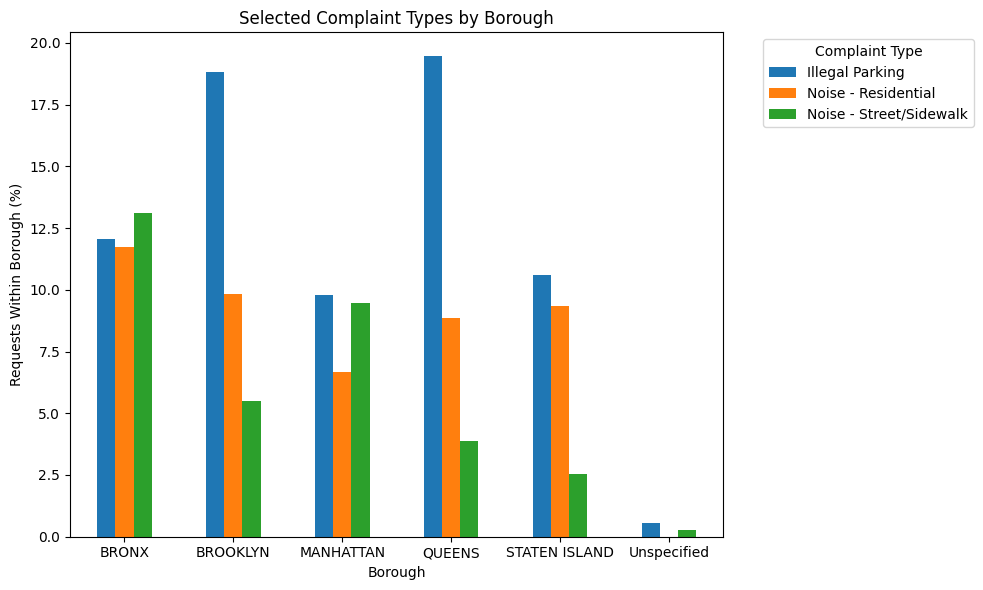

In [14]:
# Create a grouped bar chart.
ax = complaint_pct[top_types].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Selected Complaint Types by Borough")
plt.xlabel("Borough")
plt.ylabel("Requests Within Borough (%)")
plt.xticks(rotation=0)
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Read the Grouped Bar Chart

Identify:

- the boroughs,
- the complaint categories,
- the percentage axis,
- and the denominator.

### Denominator check

The displayed categories do **not** need to add to 100%.

Why?

The percentages were calculated from the **full crosstab first**, and only then were three categories selected for display.

# 9. Guided Practice: Request Status by Borough

Now apply the same workflow to a new pair of categorical variables:

- `borough`
- `status`

### Student tasks

1. Build a cross-tabulation.
2. Calculate percentages within boroughs.
3. Create a grouped bar chart.
4. Describe one difference using numerical evidence.

In [15]:
# Step 1: Count status categories within boroughs.
status_counts = pd.crosstab(
    august311["borough"],
    august311["status"]
)

status_counts

status,Assigned,Closed,In Progress,Open,Pending,Unspecified
borough,,,,,,
BRONX,151,53414,2064,8521,13,3
BROOKLYN,404,84344,9040,9921,25,7
MANHATTAN,206,52742,5310,4007,106,8
QUEENS,343,71353,8161,4738,5,2
STATEN ISLAND,109,10756,1356,908,15,0
Unspecified,3,197,150,17,0,1


In [17]:
# Step 2: Calculate percentages within each borough.
status_pct = pd.crosstab(
    august311["borough"],
    august311["status"],
    normalize="index"
).mul(100)

status_pct.round(2)

status,Assigned,Closed,In Progress,Open,Pending,Unspecified
borough,,,,,,
BRONX,0.24,83.24,3.22,13.28,0.02,0.00
BROOKLYN,0.39,81.30,8.71,9.56,0.02,0.01
MANHATTAN,0.33,84.55,8.51,6.42,0.17,0.01
QUEENS,0.41,84.34,9.65,5.60,0.01,0.00
STATEN ISLAND,0.83,81.83,10.32,6.91,0.11,0.00
Unspecified,0.82,53.53,40.76,4.62,0.00,0.27


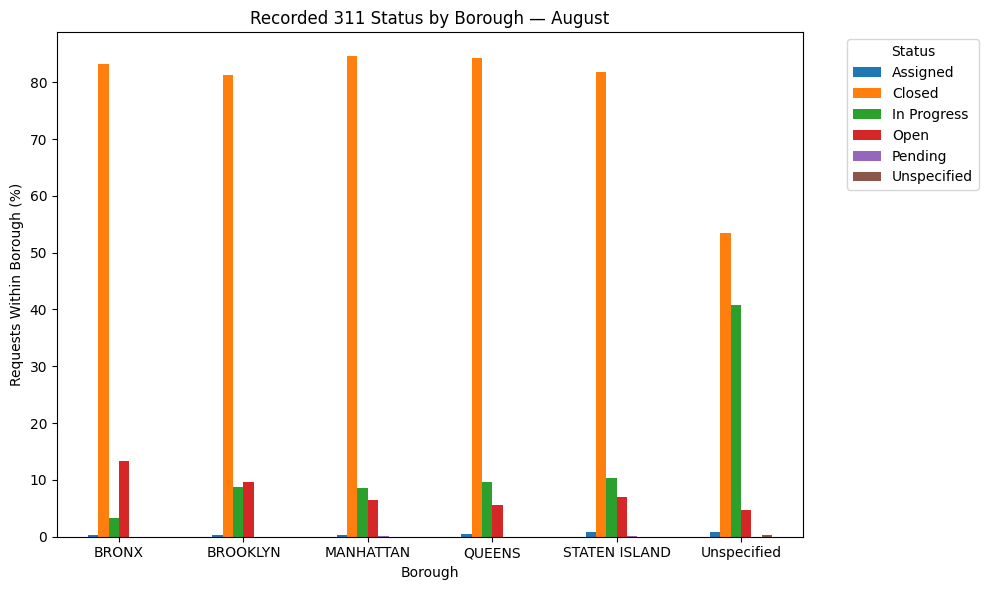

In [18]:
# Step 3: Create a grouped bar chart.
ax = status_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Recorded 311 Status by Borough — August")
plt.xlabel("Borough")
plt.ylabel("Requests Within Borough (%)")
plt.xticks(rotation=0)
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Interpretation Note: Status

A status label describes the **available administrative record**.

A label such as **Closed** does **not**, by itself, prove that:

- the underlying condition was resolved,
- the resident was satisfied,
- or service quality was the same across boroughs.

### Student finding

Write one sentence using a number from the table:

> “Within the August extract, ___% of included requests in ______ had a recorded status of ______, compared with ___% in ______.”

# 10. Meet Old Faithful

We now move from categorical comparisons to **numeric comparisons**.

The Old Faithful dataset contains observations of:

- **eruption duration**
- **waiting time**

Our main question:

> **Do longer eruptions tend to occur with longer waiting intervals?**

In [19]:
from urllib.request import urlretrieve

faithful_filename = "Old Faithful.csv"
faithful_file = os.path.join(
    os.path.dirname(os.path.abspath(csv_filename)),
    faithful_filename
)
faithful_url = (
    "https://raw.githubusercontent.com/vincentarelbundock/"
    "Rdatasets/master/csv/datasets/faithful.csv"
)

if not os.path.exists(faithful_file):
    urlretrieve(faithful_url, faithful_file)

faithful = pd.read_csv(faithful_file).drop(
    columns=["rownames"], errors="ignore"
)

In [20]:
# Summarize the two numeric variables.
faithful[["eruptions", "waiting"]].describe()

,eruptions,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


In [21]:
# Check missing values.
faithful[["eruptions", "waiting"]].isna().sum()

,0
eruptions,0
waiting,0


## Understand the Variables

Before comparing numeric variables, identify:

- What does `eruptions` measure?
- What does `waiting` measure?
- What are the units?
- Are any observations missing?

Do not interpret a numeric variable until you know what the values mean.

# 11. Create Groups for a Numeric Comparison

One way to compare a numeric outcome is to turn another numeric variable into categories.

For classroom practice, we will create two eruption-duration groups:

- **Under 3 minutes**
- **3 minutes or longer**

### Important

The three-minute cutoff is an **instructional comparison threshold**, not an established scientific classification.

Turning a numeric variable into categories makes comparison easier, but it also removes detail.

In [22]:
# Create the classroom eruption-duration groups.
# Missing eruption durations remain missing.

faithful["eruption_group"] = faithful["eruptions"].ge(3).map({
    False: "Under 3 minutes",
    True: "3 minutes or longer"
})

faithful.loc[faithful["eruptions"].isna(), "eruption_group"] = pd.NA

faithful[["eruptions", "eruption_group"]].head(10)

,eruptions,eruption_group
0,3.600,3 minutes or longer
1,1.800,Under 3 minutes
2,3.333,3 minutes or longer
3,2.283,Under 3 minutes
4,4.533,3 minutes or longer
5,2.883,Under 3 minutes
6,4.700,3 minutes or longer
7,3.600,3 minutes or longer
8,1.950,Under 3 minutes
9,4.350,3 minutes or longer


In [23]:
# Count observations in each group.
faithful.groupby("eruption_group", dropna=False).size()

,0
eruption_group,
3 minutes or longer,175
Under 3 minutes,97


## Discussion

> **What information do we lose when we turn eruption duration into only two groups?**

We lose the exact duration differences within each category.

For example, 3.1 minutes and 4.8 minutes are both placed in the same group even though their durations are different.

This is why grouping can be useful for explanation but should be done thoughtfully.

# 12. Calculate Grouped Averages

Now we have:

- a **categorical grouping variable**: `eruption_group`
- a **numeric outcome**: `waiting`

Question:

> **How does average waiting time differ between the eruption groups?**

In [24]:
avg_wait = (
    faithful
    .groupby("eruption_group")["waiting"]
    .mean()
)

avg_wait

,waiting
eruption_group,
3 minutes or longer,79.988571
Under 3 minutes,54.494845


## Interpret the Grouped Average

Read each result in **minutes**.

A careful statement describes the observed difference.

Avoid saying:

> “Long eruptions cause longer waits.”

Instead say:

> “In these observations, the mean waiting time was higher for ______ than for ______.”

That describes the data without making a causal claim.

# 13. Add Counts and Medians

A mean alone does not tell the whole story.

We can calculate several statistics at once with `.agg()`.

In [25]:
group_summary = (
    faithful
    .groupby("eruption_group")["waiting"]
    .agg(["count", "mean", "median"])
)

group_summary

,count,mean,median
eruption_group,,,
3 minutes or longer,175,79.988571,80.0
Under 3 minutes,97,54.494845,54.0


## Read the Summary Table

For each eruption group, compare:

- **count** — how many nonmissing waiting observations?
- **mean** — what is the arithmetic average?
- **median** — what is the middle waiting time?

### Discussion

1. Are the group sizes similar?
2. Do the mean and median tell a similar story?
3. What information is still missing?

Remember: grouped averages hide **variation within each group**.

# 14. Chart the Grouped Averages

A simple bar chart can communicate the difference in group means.

Because bar length represents magnitude, use a **zero baseline**.

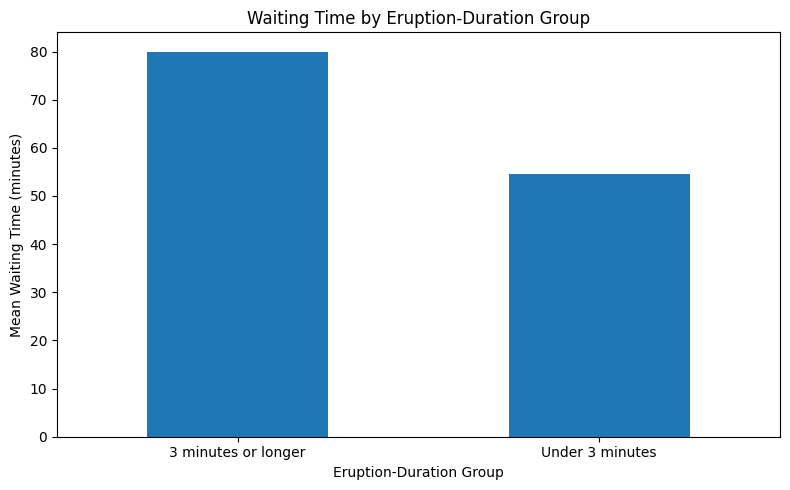

In [26]:
ax = avg_wait.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Waiting Time by Eruption-Duration Group")
plt.xlabel("Eruption-Duration Group")
plt.ylabel("Mean Waiting Time (minutes)")
plt.ylim(bottom=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Prompt

> **What would a reader still want to know about the observations within each group?**

Possible answers include:

- spread,
- minimum and maximum,
- unusual observations,
- sample size,
- and the individual paired values.

A bar chart of means simplifies the data. Next we will preserve the individual numeric observations.

# 15. Create a Scatterplot

When both variables are numeric, a scatterplot is often the best starting point.

Question:

> **What relationship appears between eruption duration and waiting time?**

Each point represents one observation with both values available.

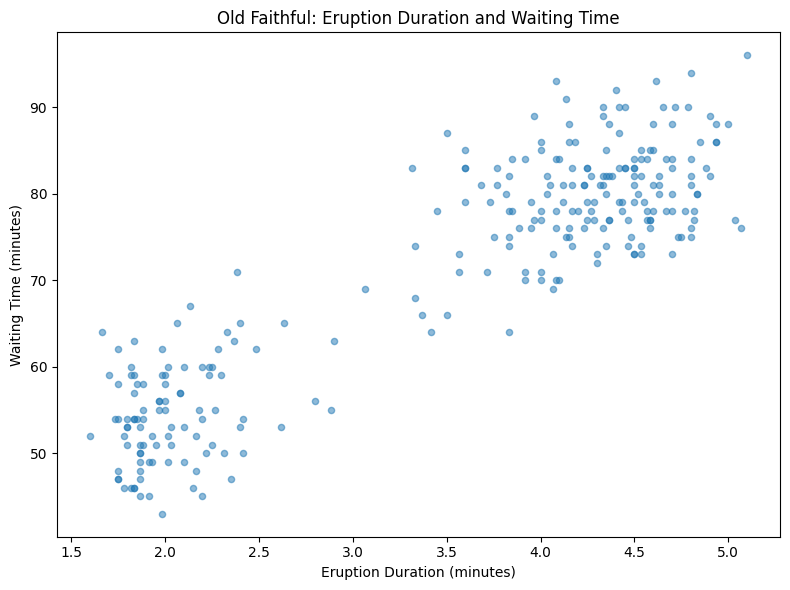

In [27]:
faithful.plot.scatter(
    x="eruptions",
    y="waiting",
    alpha=0.5,
    figsize=(8, 6)
)

plt.title("Old Faithful: Eruption Duration and Waiting Time")
plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.tight_layout()
plt.show()

## How to Read a Scatterplot

Look for four things:

### 1. Direction
Does the pattern generally move upward, downward, or neither?

### 2. Form
Does the relationship look roughly linear, curved, clustered, or irregular?

### 3. Strength
How tightly do the points follow the visible pattern?

### 4. Unusual observations
Are any points far from the rest?

Also ask:

> **How much variation remains among observations with similar eruption durations?**

# 16. Interpret the Relationship Carefully

A visible relationship is evidence of an **association**, not automatically **causation**.

A scatterplot can help us say:

> “Longer eruption durations tend to appear with longer waiting times in these observations.”

A scatterplot alone does **not** establish:

> “Longer eruptions cause longer waiting times.”

Also avoid calling a pattern **statistically significant** unless an appropriate statistical analysis has been performed.

# 17. Write a Plain-English Finding

A strong finding combines:

> **scope + comparison or pattern + evidence + limitation**

### August 311 template

> “Within the August extract, **[complaint type]** accounted for **[X]%** of included requests in **[borough A]**, compared with **[Y]%** in **[borough B]**. These percentages describe recorded requests, not the prevalence of the underlying condition.”

### Old Faithful template

> “Among observations with recorded waiting times, eruptions lasting at least three minutes had a mean waiting interval of **[X] minutes**, compared with **[Y] minutes** for shorter eruptions. This comparison depends on the selected grouping threshold.”

## What Does the Red Trendline Show?

We used **NumPy** to calculate the red trendline. `np.polyfit()` finds the slope and intercept of the straight line that best fits the points, and `np.linspace()` creates evenly spaced eruption durations so we can draw the line smoothly. Matplotlib’s `ax.plot()` adds that line to the scatterplot.

The line slopes upward: in these Old Faithful observations, longer eruptions generally go with longer waiting times. Individual points do not all lie on the line, so eruption duration does not tell us the exact waiting time for any one observation.

The trendline describes an **association** in this dataset. It does not, by itself, show that eruption duration causes the waiting time.

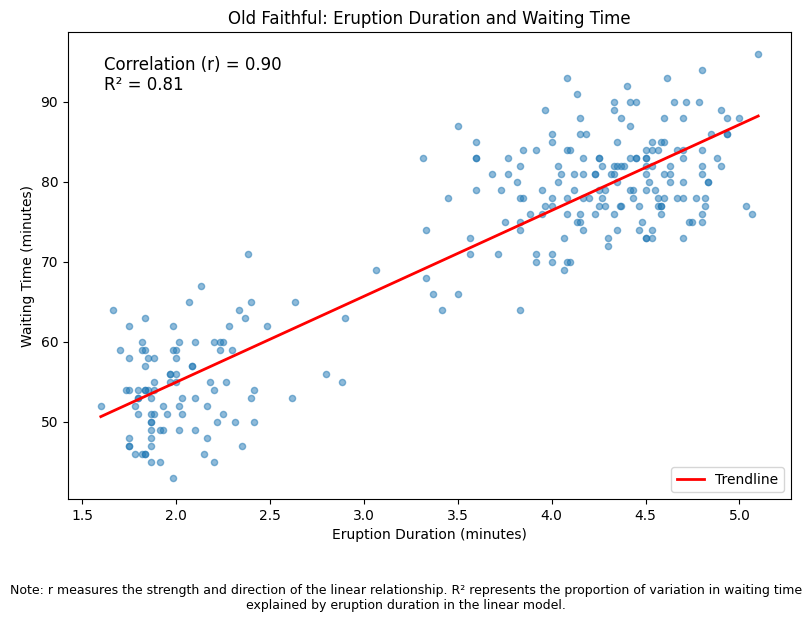

Correlation coefficient (r): 0.90
R-squared (R²): 0.81


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Keep only the columns we need and remove missing values
plot_data = faithful[["eruptions", "waiting"]].dropna()

# Calculate the correlation coefficient (r)
correlation = plot_data["eruptions"].corr(plot_data["waiting"])

# Calculate R-squared
r_squared = correlation ** 2

# Create the scatterplot
ax = plot_data.plot.scatter(
    x="eruptions",
    y="waiting",
    alpha=0.5,
    figsize=(8, 6)
)

# Calculate the trendline
slope, intercept = np.polyfit(
    plot_data["eruptions"],
    plot_data["waiting"],
    1
)

# Create values for the trendline
x_line = np.linspace(
    plot_data["eruptions"].min(),
    plot_data["eruptions"].max(),
    100
)

# Add the trendline
ax.plot(
    x_line,
    slope * x_line + intercept,
    color="red",
    linewidth=2,
    label="Trendline"
)

# Add r and R-squared to the chart
ax.text(
    0.05,
    0.95,
    f"Correlation (r) = {correlation:.2f}\nR² = {r_squared:.2f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top"
)

# Add chart labels
plt.title("Old Faithful: Eruption Duration and Waiting Time")
plt.xlabel("Eruption Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")
plt.legend()

# Add a footnote explaining r and R-squared
plt.figtext(
    0.5,
    -0.02,
    "Note: r measures the strength and direction of the linear relationship. "
    "R² represents the proportion of variation in waiting time explained by "
    "eruption duration in the linear model.",
    ha="center",
    fontsize=9,
    wrap=True
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.show()

# Print the results
print(f"Correlation coefficient (r): {correlation:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")

# 18. Independent Analysis

Choose **one** question:

1. How does complaint mix differ by borough?
2. How does recorded status differ by borough?
3. How does waiting time differ between eruption-duration groups?
4. What relationship appears between eruption duration and waiting time?

### Submit

- the question,
- Python commands,
- one summary table,
- one chart,
- one finding with numerical evidence,
- and one limitation.

Your goal is not simply to produce output. Your goal is to **explain what the output means**.

## Suggested Workflow for Independent Analysis

### Step 1 — State the question
Write the question before writing code.

### Step 2 — Identify the variable types
Are they categorical or numeric?

### Step 3 — Select the method
- categorical + categorical → crosstab / percentages
- categorical + numeric → grouped summary
- numeric + numeric → scatterplot

### Step 4 — Create a summary table
Make the comparison visible numerically.

### Step 5 — Create one appropriate chart
Label the chart clearly.

### Step 6 — Write the finding
Use numerical evidence.

### Step 7 — State a limitation
Explain what the analysis does **not** establish.

# 19. Exit Ticket

Answer in your own words.

1. How do `.size()` and `.count()` differ?
2. What does `normalize="index"` do in `pd.crosstab()`?
3. Why use a scatterplot for two numeric variables?
4. Revise this claim:

> “More 311 complaints prove that a borough has worse conditions.”

## Exit Ticket — Suggested Answers

### 1. `.size()` versus `.count()`
`.size()` counts rows in a group. `.count()` counts nonmissing values in a selected column.

### 2. `normalize="index"`
It calculates proportions within each row of a crosstab. When borough is the row variable, it calculates shares within each borough.

### 3. Why a scatterplot?
A scatterplot preserves paired numeric observations and lets us examine direction, form, variation, clusters, and unusual points.

### 4. Revised 311 claim
A better statement would be:

> “The dataset contains more recorded 311 requests for this borough during the period analyzed, but request counts alone do not establish that underlying conditions are worse.”

That version describes the evidence without claiming more than the data can support.

# 20. Connections to Later Sessions

Today's skills build toward later parts of the course.

### Data cleaning
Consistent categories and valid measurements support reliable comparisons. Missing-value checks help prevent misleading summaries.

### SQL
Grouped counts and averages connect directly to:

```sql
GROUP BY
```

Later, joins will add related information from multiple tables.

### Tableau
The same comparisons can become dashboard views. Clear labels, context, and appropriate charts help communicate findings.

### Capstone
Strong projects begin with:

- a clear question,
- appropriate evidence,
- a defensible comparison,
- and an honest statement of limitations.

> **Each skill you are learning now is a step toward more powerful analyses and more meaningful insights.**

# 21. End-of-Class Review Questions and Answers

### Q1. What makes an analysis bivariate?
It examines two variables together.

### Q2. When would we use a cross-tabulation?
When both variables are categorical and we want to examine combinations of categories.

### Q3. Why might percentages be more useful than raw counts?
Percentages can make category composition easier to compare when group totals differ.

### Q4. What must we identify before interpreting a percentage?
The denominator.

### Q5. What does `groupby()` do?
It splits observations into groups so a summary can be calculated for each group.

### Q6. What is a grouped average?
The mean of a numeric variable calculated separately for each category.

### Q7. Why should we look at count and median as well as mean?
They provide information about group size and center that a mean alone does not show.

### Q8. Why use a scatterplot for eruption duration and waiting time?
Both variables are numeric, and the scatterplot preserves the paired values.

### Q9. Does a visible scatterplot relationship prove causation?
No. It shows an observed association, not necessarily a causal effect.

### Q10. What should a strong finding contain?
Scope, a comparison or pattern, numerical evidence, and an appropriate limitation.